In [62]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Modelo XGBoost

In [63]:
df = pd.read_csv('obesity.csv')


In [64]:
df.head()
df.info()
df.describe()
df.dtypes
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

(2111, 17)

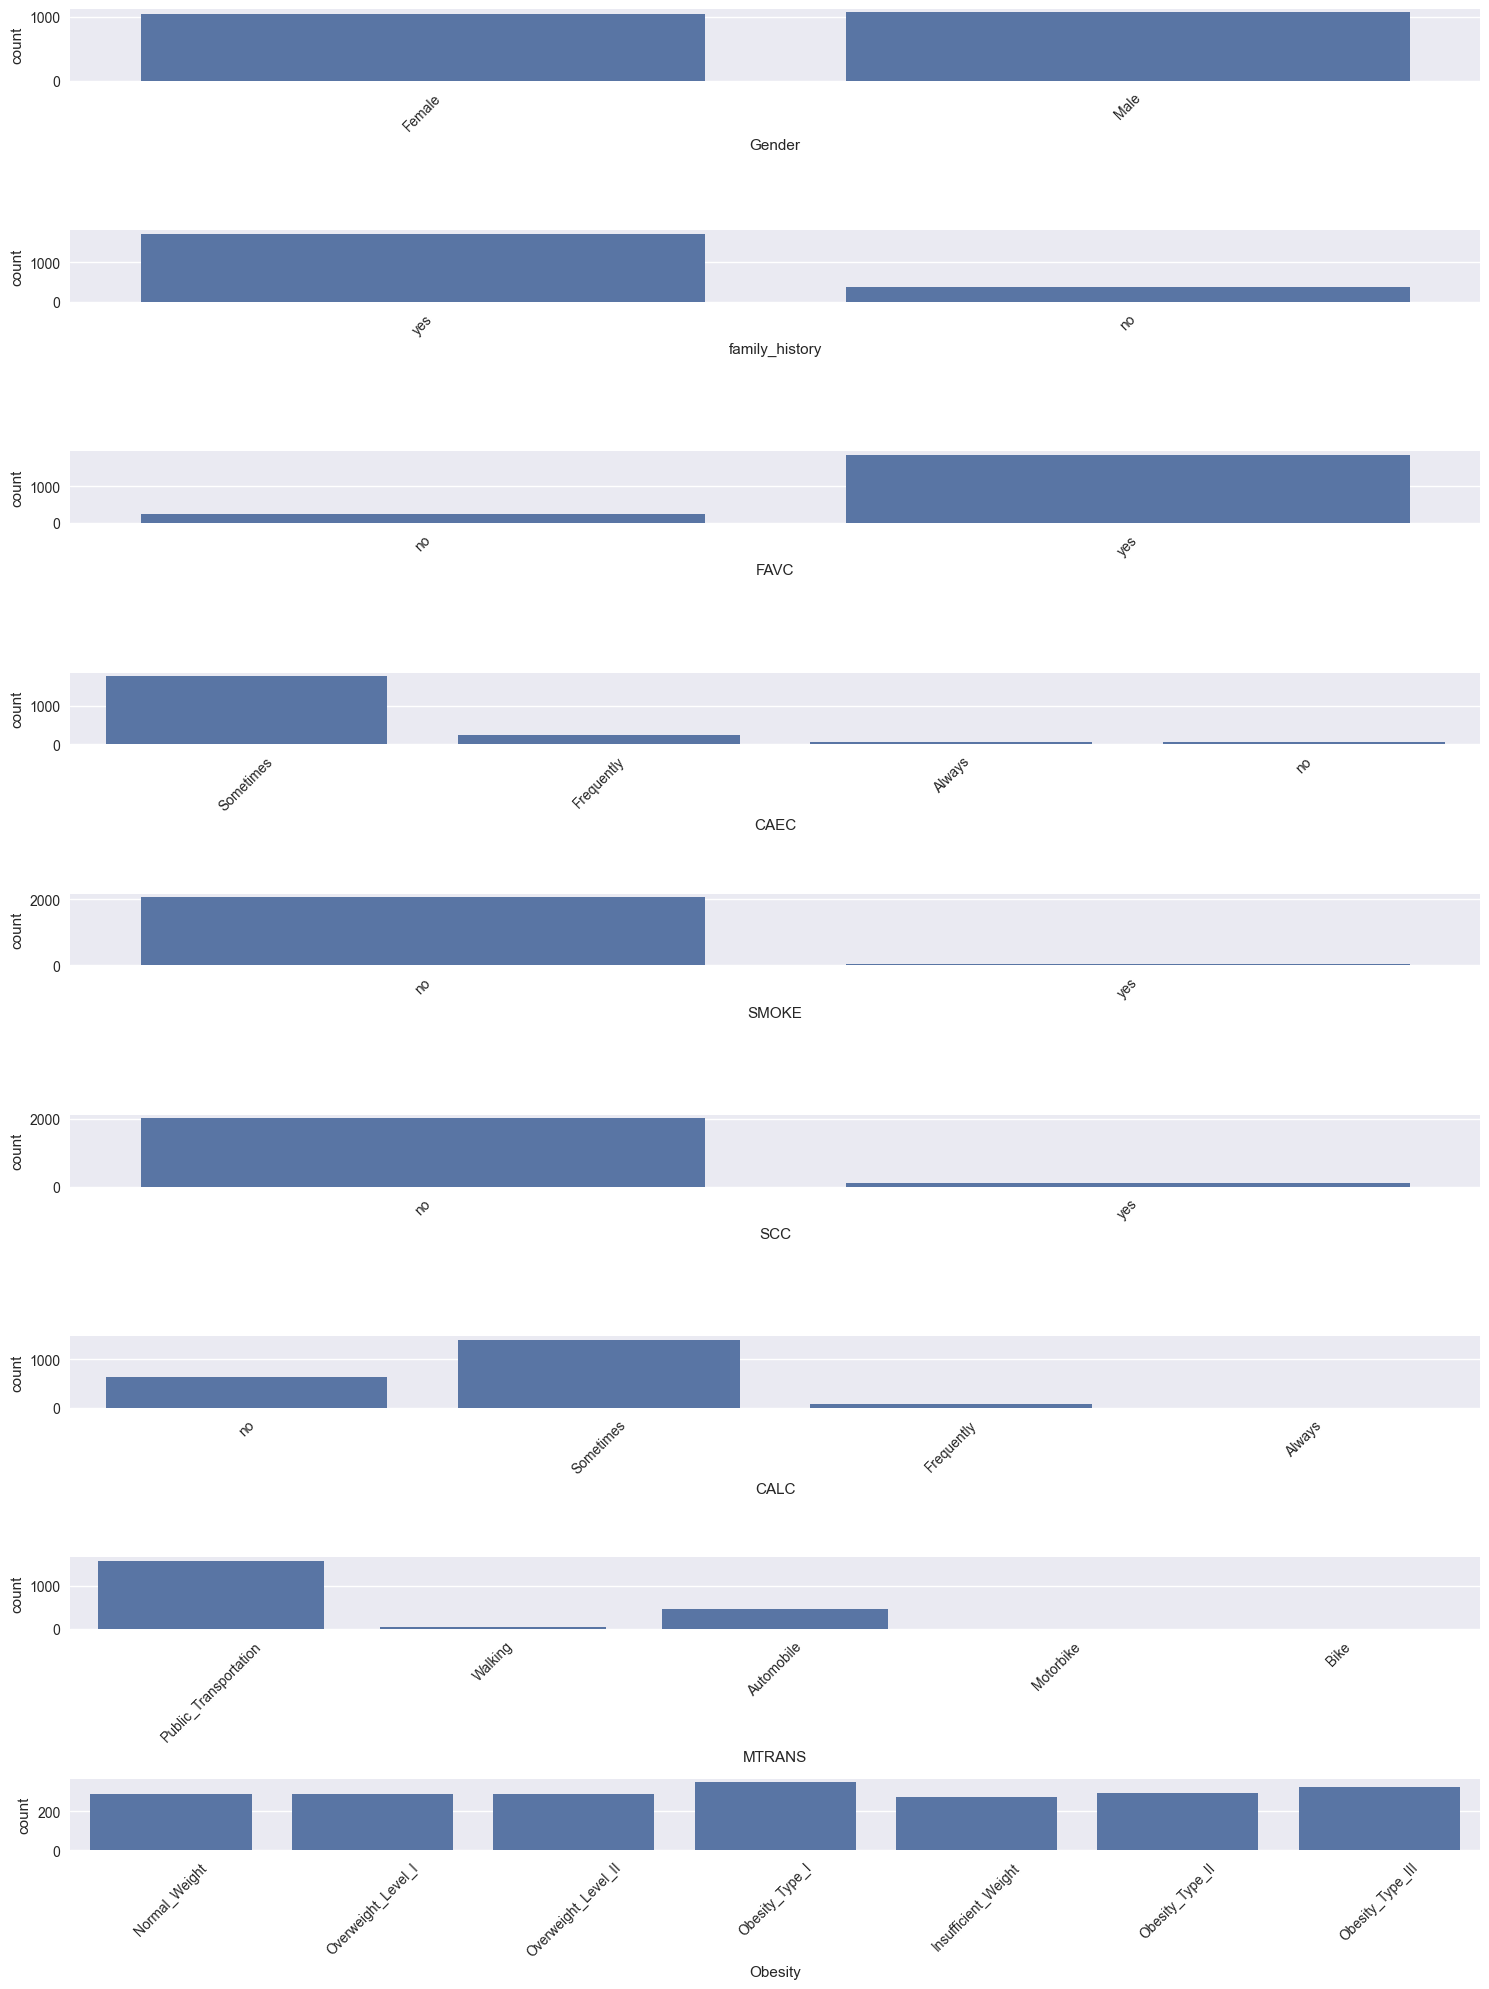

In [65]:
plt.style.use('seaborn-v0_8')

cat_cols = df.select_dtypes(include=['object']).columns

plt.figure(figsize=(15, 20))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(len(cat_cols), 1, i)
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


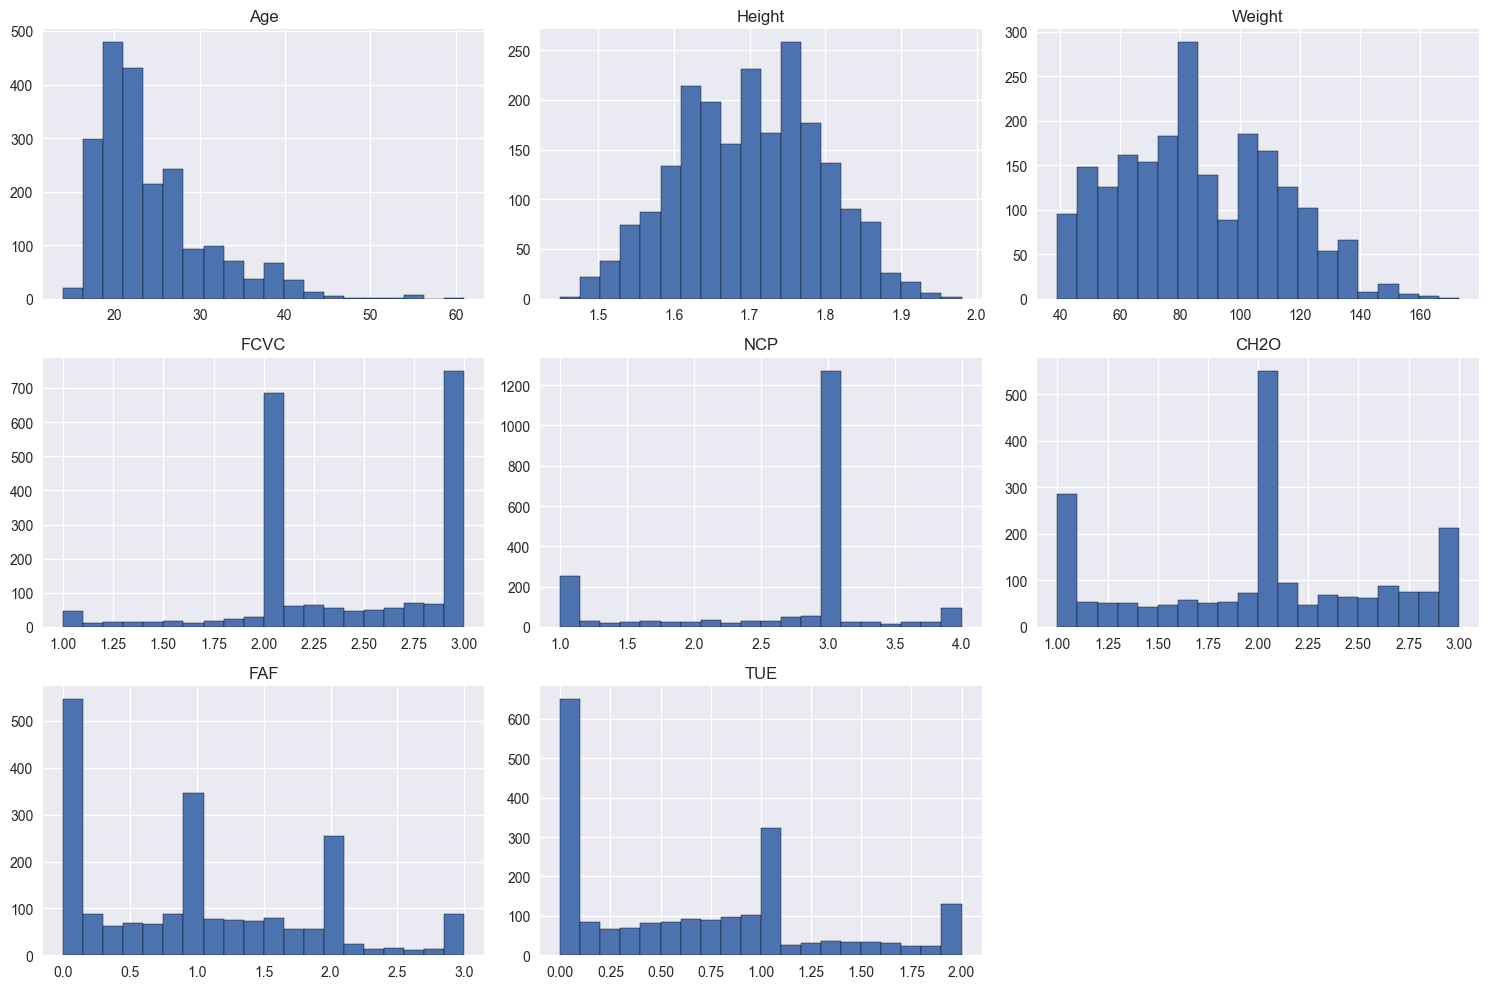

In [66]:
num_cols = df.select_dtypes(include=['float64']).columns

df[num_cols].hist(figsize=(15,10), bins=20, edgecolor='black')
plt.tight_layout()
plt.show()


In [67]:
X = df.drop('Obesity', axis=1)
y = df['Obesity']


In [68]:
le = LabelEncoder()
y = le.fit_transform(y)


In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [70]:
num_cols = X.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X.select_dtypes(include=['object']).columns


In [71]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [72]:
model = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5
)

In [73]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])

In [74]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='accuracy'
)

print("Acurácias por fold:", cv_scores)
print("Acurácia média (CV):", cv_scores.mean())


Acurácias por fold: [0.97928994 0.98224852 0.9704142  0.96439169 0.97329377]
Acurácia média (CV): 0.9739276245325094


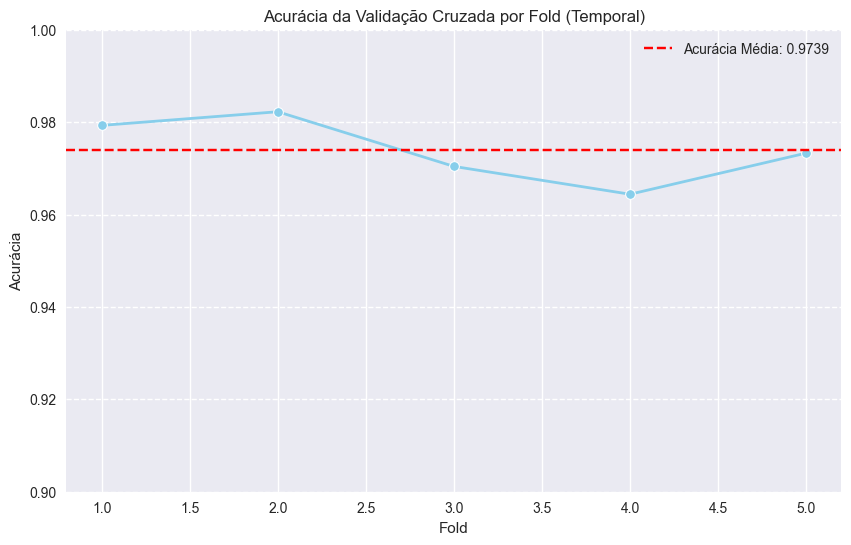

In [75]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=np.arange(1, len(cv_scores) + 1), y=cv_scores, marker='o', color='skyblue', linewidth=2)
plt.axhline(cv_scores.mean(), color='r', linestyle='--', label=f'Acurácia Média: {cv_scores.mean():.4f}')
plt.title('Acurácia da Validação Cruzada por Fold (Temporal)')
plt.xlabel('Fold')
plt.ylabel('Acurácia')
plt.ylim(0.9, 1.0)
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.show()

In [76]:
pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [77]:
y_pred = pipeline.predict(X_test)

print("Acurácia no teste:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred))


Acurácia no teste: 0.9574468085106383

Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.96      0.91      0.93        54
           1       0.83      0.95      0.89        58
           2       0.97      0.99      0.98        70
           3       0.98      0.98      0.98        60
           4       1.00      0.98      0.99        65
           5       0.98      0.90      0.94        58
           6       0.98      0.98      0.98        58

    accuracy                           0.96       423
   macro avg       0.96      0.96      0.96       423
weighted avg       0.96      0.96      0.96       423



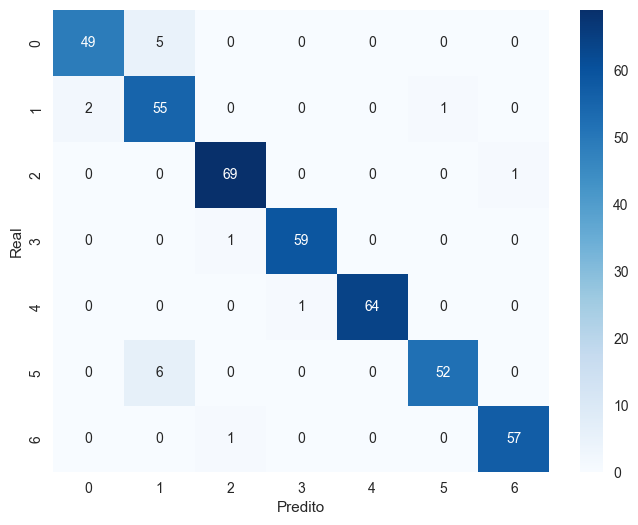

In [78]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()


In [79]:
if os.path.exists('modelo_obesity.joblib'):
    os.remove('modelo_obesity.joblib')
joblib.dump(pipeline, 'modelo_obesity.joblib')

print("Modelo salvo como 'modelo_obesity.joblib'")

Modelo salvo como 'modelo_obesity.joblib'


In [80]:
if os.path.exists('label_encoder_obesity.joblib'):
    os.remove('label_encoder_obesity.joblib')
joblib.dump(le, 'label_encoder_obesity.joblib')

print("LabelEncoder salvo como 'label_encoder_obesity.joblib'")

LabelEncoder salvo como 'label_encoder_obesity.joblib'


In [81]:
data = {
    'Gender': 'Female',
    'Age': 24,
    'Height': 1.65,
    'Weight': 80.0,
    'family_history': 'yes',
    'FAVC': 'yes',
    'FCVC': 2.0,
    'NCP': 3.0,
    'CAEC': 'Sometimes',
    'SMOKE': 'no',
    'CH2O': 2.0,
    'SCC': 'no',
    'FAF': 0.0,
    'TUE': 1.0,
    'CALC': 'Sometimes',
    'MTRANS': 'Public_Transportation'
}

import pandas as pd

input_df = pd.DataFrame([data])

import joblib

loaded_model = joblib.load('modelo_obesity.joblib')

prediction = loaded_model.predict(input_df)
prediction_proba = loaded_model.predict_proba(input_df)
confidence = max(prediction_proba[0]) * 100

le = joblib.load('label_encoder_obesity.joblib')

prediction_label = le.inverse_transform(prediction)

print(f"Prediction for the input data: {prediction_label[0]}")
print(f"Prediction for the input data percentage: ({confidence:.2f}%)")

Prediction for the input data: Overweight_Level_II
Prediction for the input data percentage: (96.55%)


In [82]:
if "OBESITY" in prediction_label[0].upper() or "OVERWEIGHT" in prediction_label[0].upper():
    print("Obesidade: Sim")
else:
    print("Obesidade: Não")

Obesidade: Sim
